# Supermarket Sales Analytics - Exploratory Data Analysis (EDA)

## Objective
This notebook explores the dataset to identify key business insights across:
- Revenue and profit trends
- Customer behaviour
- Product performance
- Regional performance
- Inventory and operational risks

## Goal
To generate actionable insights that support business decision-making.

### Insight:
- Category X generates the highest revenue
- Category Y has lower profitability despite strong sales

In [19]:
# -------------------------------
# STEP 2: Import libraries and load processed dataset
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned and enhanced dataset created in the previous notebook
sales_data = pd.read_csv("../data/processed/enhanced_supermarket.csv")

# Preview data
sales_data.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,stock_quantity,reorder_level,stock_status,high_demand_low_stock_flag,loss_making_flag,high_discount_flag,high_sales_low_profit_flag,shipping_days,shipping_speed,region_performance
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,122,18,Stock OK,0,0,0,0,3,Standard,Low Performing
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,199,43,Stock OK,0,0,0,0,3,Standard,Low Performing
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,112,36,Stock OK,0,0,0,0,4,Standard,High Performing
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,34,39,Reorder Needed,1,0,0,0,7,Slow,Low Performing
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,126,27,Stock OK,0,0,0,0,7,Slow,Low Performing


In [20]:
# Dataset shape
# -------------------------------
# STEP 3: Basic dataset overview
# -------------------------------

# Check dataset dimensions (rows, columns)
print("Shape:", sales_data.shape)

# View column names
print("\nColumns:\n", sales_data.columns.tolist())

# Summary statistics for numerical columns
sales_data.describe()

Shape: (9800, 51)

Columns:
 ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month', 'order_month_name', 'order_day_name', 'order_quarter', 'is_weekend', 'quantity', 'discount', 'estimated_cost_ratio', 'estimated_cost', 'estimated_discount_value', 'estimated_unit_price', 'estimated_unit_cost', 'estimated_profit', 'estimated_profit_margin', 'customer_total_revenue', 'customer_order_count', 'customer_avg_order_value', 'customer_value_segment', 'order_total_sales', 'order_total_quantity', 'order_total_profit', 'bulk_order_flag', 'stock_quantity', 'reorder_level', 'stock_status', 'high_demand_low_stock_flag', 'loss_making_flag', 'high_discount_flag', 'high_sales_low_profit_flag', 'shipping_days', 'shipping_speed', 'region_performance']


,row_id,postal_code,sales,order_year,order_month,order_quarter,quantity,discount,estimated_cost_ratio,estimated_cost,...,order_total_quantity,order_total_profit,bulk_order_flag,stock_quantity,reorder_level,high_demand_low_stock_flag,loss_making_flag,high_discount_flag,high_sales_low_profit_flag,shipping_days
count,9800.000000,9789.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.00000,9800.000000,9800.000000,9800.000000,...,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.0,9800.000000,9800.0,9800.000000
mean,4900.500000,55273.322403,230.769059,2016.724184,7.818469,2.885816,4.00949,0.071378,0.595188,150.444564,...,11.950204,245.901021,0.525612,134.346633,36.893571,0.022347,0.0,0.047143,0.0,3.961122
std,2829.160653,32041.223413,626.651875,1.123984,3.281905,1.057449,1.99837,0.085415,0.112179,445.922516,...,8.521775,406.403966,0.499369,65.645878,12.790516,0.147817,0.0,0.211955,0.0,1.749614
min,1.000000,1040.000000,0.444000,2015.000000,1.000000,1.000000,1.00000,0.000000,0.400012,0.208632,...,1.000000,0.266249,0.000000,20.000000,15.000000,0.000000,0.0,0.000000,0.0,0.000000
25%,2450.750000,23223.000000,17.248000,2016.000000,5.000000,2.000000,2.00000,0.000000,0.507262,9.358949,...,6.000000,32.764556,0.000000,78.000000,26.000000,0.000000,0.0,0.000000,0.0,3.000000
50%,4900.500000,58103.000000,54.490000,2017.000000,9.000000,3.000000,4.00000,0.050000,0.590737,31.681144,...,10.000000,114.855460,1.000000,134.000000,36.000000,0.000000,0.0,0.000000,0.0,4.000000
75%,7350.250000,90008.000000,210.605000,2018.000000,11.000000,4.000000,6.00000,0.100000,0.671559,133.155008,...,16.000000,291.721503,1.000000,189.000000,48.000000,0.000000,0.0,0.000000,0.0,5.000000
max,9800.000000,99301.000000,22638.480000,2018.000000,12.000000,4.000000,7.00000,0.300000,0.849974,16832.960724,...,58.000000,6114.792559,1.000000,249.000000,59.000000,1.000000,0.0,1.000000,0.0,7.000000


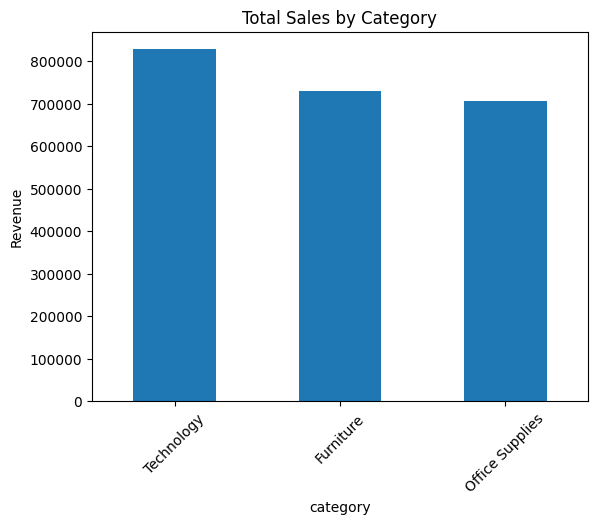

In [21]:
# -------------------------------
# STEP 4: Analyse total revenue by product category
# -------------------------------

# Group data by category and calculate total sales
category_sales = sales_data.groupby("category")["sales"].sum().sort_values(ascending=False)

# Plot bar chart
category_sales.plot(kind="bar")

# Add titles and labels
plt.title("Total Sales by Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display chart
plt.show()

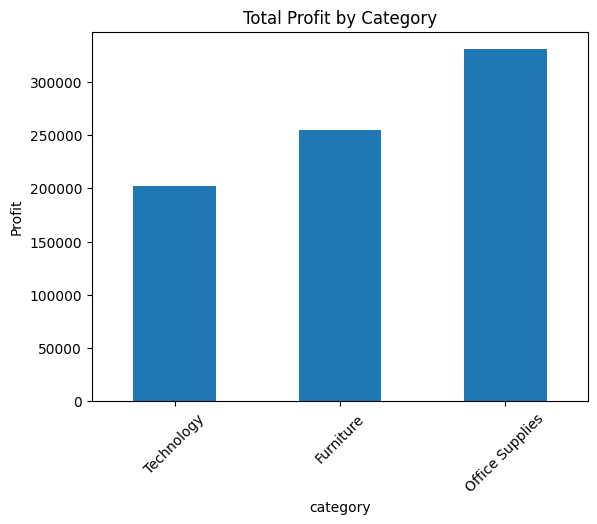

In [22]:
# -------------------------------
# STEP 5: Analyse profitability by category
# -------------------------------

# Calculate total estimated profit per category
category_profit = sales_data.groupby("category")["estimated_profit"].sum().sort_values()

# Plot bar chart
category_profit.plot(kind="bar")

# Add titles
plt.title("Total Profit by Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)

# Display chart
plt.show()

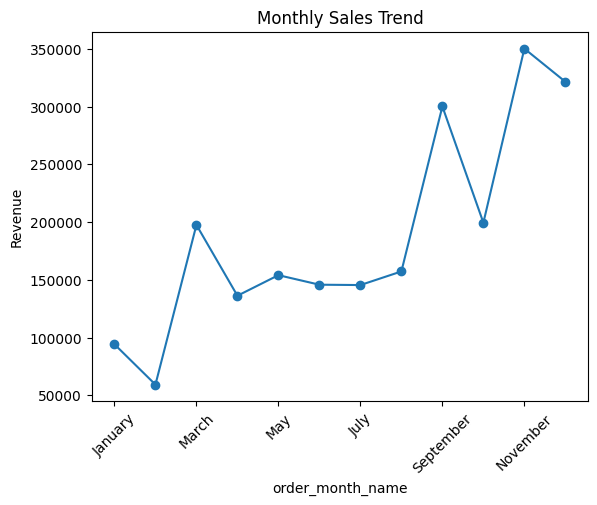

In [23]:
# -------------------------------
# STEP 6: Analyse sales trend over months
# -------------------------------

# Aggregate sales by month name
monthly_sales = sales_data.groupby("order_month_name")["sales"].sum()

# Reorder months for proper chronological display
monthly_sales = monthly_sales.reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

# Plot line chart
monthly_sales.plot(kind="line", marker="o")

# Add titles
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display chart
plt.show()

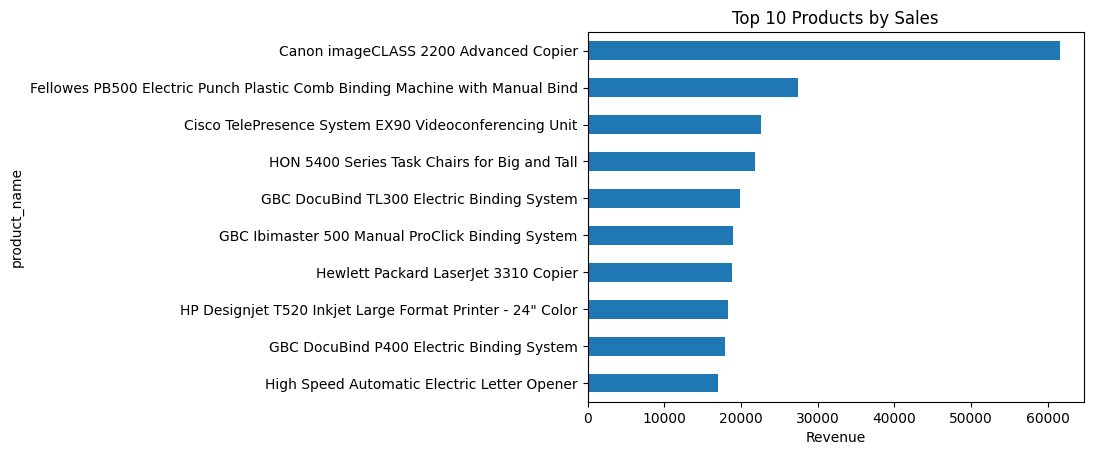

In [24]:
# -------------------------------
# STEP 7: Identify top 10 products by sales
# -------------------------------

# Aggregate sales by product name
top_products = (
    sales_data.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot horizontal bar chart
top_products.plot(kind="barh")

# Add titles
plt.title("Top 10 Products by Sales")
plt.xlabel("Revenue")

# Invert axis so highest value is on top
plt.gca().invert_yaxis()

# Display chart
plt.show()

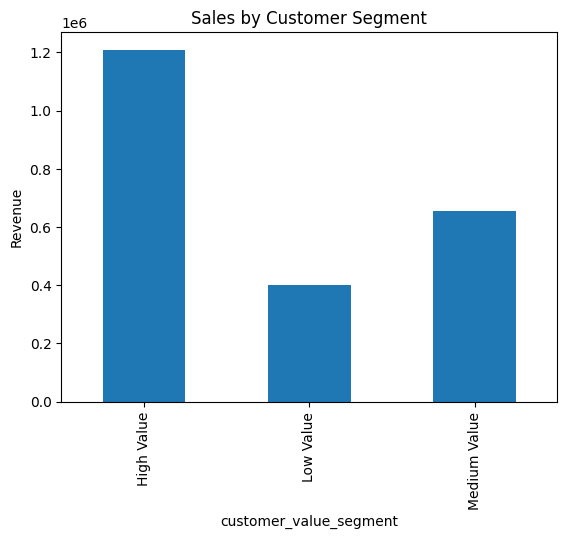

In [25]:
# -------------------------------
# STEP 8: Analyse revenue by customer segment
# -------------------------------

# Aggregate sales by customer value segment
customer_segment_sales = sales_data.groupby("customer_value_segment")["sales"].sum()

# Plot bar chart
customer_segment_sales.plot(kind="bar")

# Add titles
plt.title("Sales by Customer Segment")
plt.ylabel("Revenue")

# Display chart
plt.show()

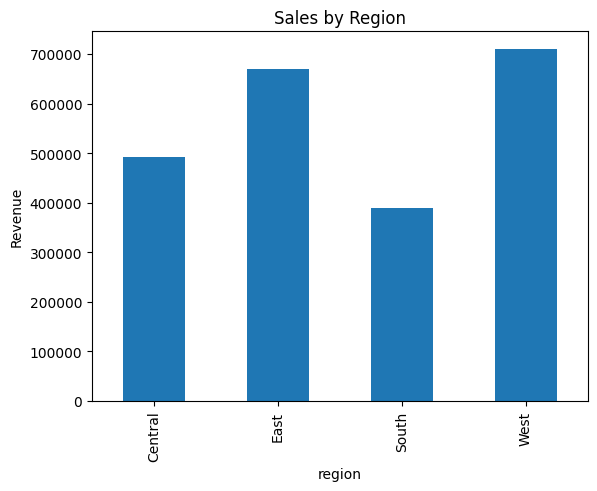

In [26]:
# -------------------------------
# STEP 9: Analyse sales by region
# -------------------------------

# Aggregate sales by region
region_sales = sales_data.groupby("region")["sales"].sum()

# Plot bar chart
region_sales.plot(kind="bar")

# Add titles
plt.title("Sales by Region")
plt.ylabel("Revenue")

# Display chart
plt.show()

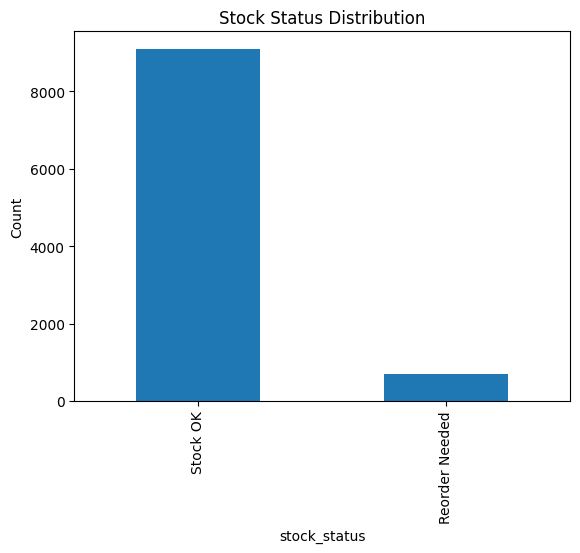

In [27]:
# -------------------------------
# STEP 10: Analyse stock status distribution
# -------------------------------

# Count number of products by stock status
stock_status_counts = sales_data["stock_status"].value_counts()

# Plot bar chart
stock_status_counts.plot(kind="bar")

# Add titles
plt.title("Stock Status Distribution")
plt.ylabel("Count")

# Display chart
plt.show()

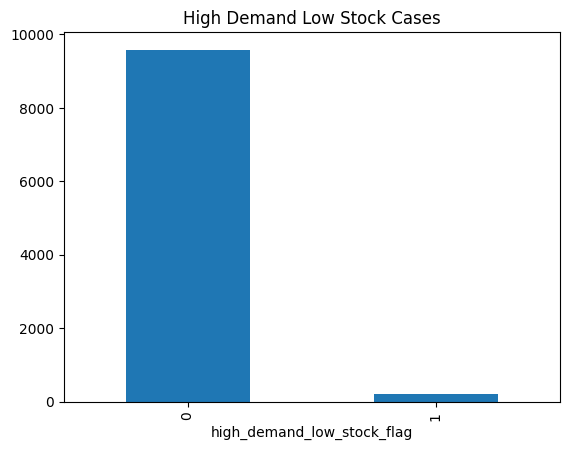

In [28]:
# -------------------------------
# STEP 11: Identify high demand but low stock situations
# -------------------------------

# Count number of high-risk cases
risk_cases = sales_data["high_demand_low_stock_flag"].value_counts()

# Plot bar chart
risk_cases.plot(kind="bar")

# Add titles
plt.title("High Demand Low Stock Cases")

# Display chart
plt.show()

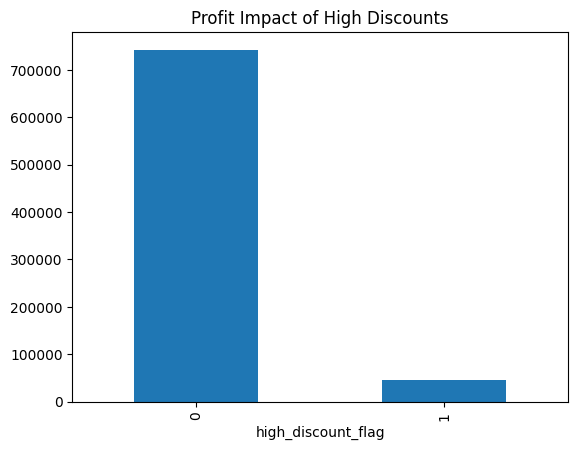

In [29]:
# -------------------------------
# STEP 12: Analyse impact of high discounts on profit
# -------------------------------

# Group profit by discount flag
discount_impact = sales_data.groupby("high_discount_flag")["estimated_profit"].sum()

# Plot bar chart
discount_impact.plot(kind="bar")

# Add titles
plt.title("Profit Impact of High Discounts")

# Display chart
plt.show()